# 10 — Comparaison inter-familles aux standards de publication

Les notebooks 07 à 09 donnent des estimations ponctuelles sur 62 points de test. Trois choses manquent pour qu'un tableau comparatif tienne en relecture, et ce notebook les ajoute.

**1. Un jeu d'entraînement commun.** Au notebook 08, le ML pur était entraîné sur les 261 points de Dev tandis que les hybrides l'étaient sur les 242 points filtrés à d ≥ 1 km, puisque Ê_L2 n'y est défini que là. Comparer des modèles entraînés sur des jeux différents n'est pas une comparaison. Ici **toutes les familles sont entraînées sur les 242 points de Dev filtré et évaluées sur les 62 points de test filtré**. La variante « ML pur entraîné sur Dev entier » est conservée en ligne secondaire, pour mesurer ce que coûte la contrainte.

**2. Des intervalles de confiance.** Avec 62 points, l'erreur type du RMSE vaut environ RMSE/√(2n) ≈ 0.4 dB. Toute différence inférieure à ~0.8 dB est dans le bruit d'échantillonnage. On donne donc un intervalle de confiance bootstrap à 95 % (2000 rééchantillonnages percentile) sur RMSE, MAE, R² et biais.

**3bis. Le représentant de chaque famille est choisi dans Dev.** Mettre en avant le modèle qui obtient le meilleur RMSE *de test* serait encore une sélection sur le test. Les représentants sont donc désignés par leur RMSE de validation dans Dev, et l'écart avec un choix fait sur le test est rapporté comme diagnostic.

**3. Des tests appariés.** Un classement entre modèles n'est affirmable que si la différence est significative. Pour chaque comparaison on donne la différence de RMSE avec son intervalle bootstrap **apparié** (mêmes points rééchantillonnés pour les deux modèles), la proportion de rééchantillonnages où A bat B, et un test de Wilcoxon apparié sur les erreurs absolues, corrigé pour la multiplicité par la méthode de Holm.

Le test n'est lu qu'ici, et les décisions de modélisation — ordre de Borda, N\*, hyperparamètres — viennent toutes des notebooks 07 et 08, où elles ont été prises dans Dev.


---
## §0 — Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

BASE = Path('.').resolve()
NB07, NB08 = BASE / 'outputs_nb07', BASE / 'outputs_nb08'
OUT = BASE / 'outputs_nb10'; OUT.mkdir(exist_ok=True)

SEED, TARGET = 42, 'E_field'
np.random.seed(SEED)
N_BOOT = 2000
ML_NAMES = ['RF', 'XGBoost', 'CatBoost', 'LightGBM']

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

with open(NB07 / 'best_params_dev.json') as f:
    BEST = json.load(f)

imp_multi = pd.read_csv(NB07 / 'feature_importance_multi_dev.csv', index_col=0)
TIE = ['First_building_m', 'Fresnel_trees']
BORDA_ORDER = []
for r in sorted(imp_multi['Borda_rank'].unique()):
    g = imp_multi[imp_multi['Borda_rank'] == r].index.tolist()
    if len(g) > 1:
        g = [f for f in TIE if f in g] + [f for f in g if f not in TIE]
    BORDA_ORDER.extend(g)

# Pure ML N* sélectionné dans Dev FILTRÉ (nb08 §5), même domaine que Hata calibré et les
# hybrides — pas le N* de nb07 (choisi sur tout Dev, réservé à Table 6 uniquement).
hyb = pd.read_csv(NB08 / 'nstar_hybrides_dev.csv')
NSTAR_PUREML = dict(zip(hyb['Model'], hyb['PureML_N*_filtered']))
NSTAR_PUREML = {k: int(v) for k, v in NSTAR_PUREML.items()}
NSTAR_A1 = dict(zip(hyb['Model'], hyb['A1_N*'].astype(int)))
NSTAR_A2 = dict(zip(hyb['Model'], hyb['A2_N*'].astype(int)))

def build_ml(name):
    p = BEST[name].copy()
    if name == 'RF':       return RandomForestRegressor(random_state=SEED, n_jobs=-1, **p)
    if name == 'XGBoost':  return XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0, **p)
    if name == 'CatBoost': return CatBoostRegressor(random_seed=SEED, verbose=0, thread_count=-1, **p)
    if name == 'LightGBM': return lgb.LGBMRegressor(random_state=SEED, n_jobs=-1, verbose=-1, **p)

print('Décisions reprises des notebooks 07 et 08 :')
print('  N* Pure ML :', NSTAR_PUREML)
print('  N* A1      :', NSTAR_A1)
print('  N* A2      :', NSTAR_A2)

Décisions reprises des notebooks 07 et 08 :
  N* Pure ML : {'RF': 5, 'XGBoost': 5, 'CatBoost': 5, 'LightGBM': 5}
  N* A1      : {'RF': 3, 'XGBoost': 4, 'CatBoost': 3, 'LightGBM': 13}
  N* A2      : {'RF': 3, 'XGBoost': 5, 'CatBoost': 5, 'LightGBM': 7}


---
## §1 — Données, split, et jeu d'entraînement commun

In [2]:
df = pd.read_csv(BASE / 'radio_features_clean_ref.csv')
FEAT_GROUPS = {
    'System':    ['Tx_power', 'Tx_height', 'Freq'],
    'Distance':  ['Distance'],
    'Terrain':   ['Slope_Tx_Rx_50m', 'Roughness_Tx_Rx_50m', 'Rx_height'],
    'Geometry':  ['Azimut_Tx_Rx', 'Tilt_Tx_Rx'],
    'Obstacles': ['LOS', 'First_building_m', 'First_tree_m', 'Fresnel_buildings',
                  'Fresnel_trees', 'Buildings_near_Rx', 'Trees_near_Rx'],
    'Weather':     ['Temp', 'Rhum'],
    'Context':   ['Environment'],
}
ALL_FEATURES = [f for feats in FEAT_GROUPS.values() for f in feats]

dev_df, test_df = train_test_split(df, test_size=0.20, random_state=SEED,
                                   stratify=df['Environment'])
dev_df, test_df = dev_df.reset_index(drop=True), test_df.reset_index(drop=True)
dev_f  = dev_df[dev_df['Distance']  >= 1000.0].copy().reset_index(drop=True)
test_f = test_df[test_df['Distance'] >= 1000.0].copy().reset_index(drop=True)
y_dev_f, y_test_f = dev_f[TARGET].values, test_f[TARGET].values
env_test_f = test_f['Environment'].values
n_test = len(y_test_f)

print(f'Jeu d entraînement commun : Dev filtré, n = {len(dev_f)}')
print(f'Jeu de test               : Test filtré, n = {n_test} '
      f'(urbain {int((env_test_f==1).sum())}, suburbain {int((env_test_f==0).sum())})')
print(f'Erreur type attendue du RMSE ≈ RMSE/√(2n) = RMSE/{np.sqrt(2*n_test):.1f}')

Jeu d entraînement commun : Dev filtré, n = 242
Jeu de test               : Test filtré, n = 62 (urbain 39, suburbain 23)
Erreur type attendue du RMSE ≈ RMSE/√(2n) = RMSE/11.1


---
## §2 — Prédictions de toutes les familles

Tout est entraîné sur les 242 points communs. Aucune décision n'est prise ici : N\*, hyperparamètres et ordre des features viennent de Dev.

In [3]:
# ── Hata et calibration, estimés sur Dev filtré ─────────────────────────────
def okumura_hata_efield(f, d_m, h_b, h_m, erp, urban):
    d_km = d_m / 1000.0
    if d_km < 1.0: return np.nan
    a_hm = 3.2*(np.log10(11.75*h_m))**2 - 4.97
    Lu = (69.55 + 26.16*np.log10(f) - 13.82*np.log10(h_b) - a_hm
          + (44.9 - 6.55*np.log10(h_b))*np.log10(d_km))
    L = Lu if urban else Lu - 2*(np.log10(f/28))**2 - 5.4
    L = max(L, 32.45 + 20*np.log10(d_km) + 20*np.log10(f))
    return 10*np.log10(erp) + 32.15 - L + 20*np.log10(f) + 77.2

def apply_hata(d):
    return d.apply(lambda r: okumura_hata_efield(
        r['Freq'], r['Distance'], r['Tx_antenna_height'],
        r['Rx_antenna_height'], r['Tx_power'], bool(r['Environment'])), axis=1).values

hata_dev, hata_test = apply_hata(dev_f), apply_hata(test_f)
res_dev = y_dev_f - hata_dev
delta_global = float(res_dev.mean())
deltas_env = {e: float(res_dev[dev_f['Environment'].values == e].mean()) for e in (0, 1)}

def build_ols_df(d):
    d_km = d['Distance'].values/1000.0
    h_b, h_m = d['Tx_antenna_height'].values, d['Rx_antenna_height'].values
    return pd.DataFrame({'log_d': np.log10(d_km), 'log_f': np.log10(d['Freq'].values),
                         'log_hb': np.log10(h_b), 'a_hm': 3.2*(np.log10(11.75*h_m))**2 - 4.97,
                         'log_hb_log_d': np.log10(h_b)*np.log10(d_km),
                         'log_erp': np.log10(d['Tx_power'].values),
                         'Environment': d['Environment'].values.astype(float)})

ols_l2 = sm.OLS(y_dev_f, sm.add_constant(build_ols_df(dev_f))).fit()
e_l2_dev  = ols_l2.predict(sm.add_constant(build_ols_df(dev_f))).values
e_l2_test = ols_l2.predict(sm.add_constant(build_ols_df(test_f))).values
delta_l2_dev = y_dev_f - e_l2_dev

In [4]:
# ── ITU-R P.1546-6 ──────────────────────────────────────────────────────────
D_KM = np.array([1.,2.,3.,4.,5.,6.,7.,8.,9.,10.]); H1 = np.array([75.,150.,300.])
T100 = np.array([[75.,69.5,65.5,62.5,59.5,57.,54.5,52.5,51.,49.],
                 [80.,74.5,70.5,67.5,64.5,62.,59.5,57.5,56.,54.],
                 [85.5,80.,76.,73.,70.,67.5,65.,63.,61.5,59.5]])
T600 = np.array([[71.,63.5,58.5,54.5,51.,48.,45.5,43.5,41.5,40.],
                 [77.,69.5,64.5,60.5,57.,54.,51.5,49.5,47.5,46.],
                 [83.,75.5,70.5,66.5,63.,60.,57.5,55.5,53.5,52.]])
C_TROP = (100.0 - 43.3)/20.0

def _ih(tb, h1_m, d_km):
    e = np.array([np.interp(np.log10(np.clip(d_km, D_KM[0], D_KM[-1])), np.log10(D_KM), tb[i]) for i in range(3)])
    return np.interp(np.log10(np.clip(h1_m, H1[0], H1[-1])), np.log10(H1), e)

def _h2c(f, d_km, h1, h2, urban):
    R2 = 15.0 if urban else 10.0
    R2p = max(1.0, (1000.*d_km*R2 - 15.*h1)/(1000.*d_km - 15.)) if urban else R2
    R2p = np.clip(R2p, 1.0, R2); K = 3.2 + 6.2*np.log10(f)
    if h2 < R2p:
        nu = 0.0108*np.sqrt(f)*np.sqrt((R2p-h2)*np.degrees(np.arctan((R2p-h2)/27.)))
        J = (6.9 + 20.*np.log10(np.sqrt((nu-0.1)**2+1.)+nu-0.1)) if nu > -0.7806 else 0.
        c = 6.03 - J
    else:
        c = K*np.log10(h2/R2p)
    return c - (K*np.log10(10./R2p) if (urban and R2p < 10.) else 0.)

def itu_p1546(r):
    d_km, f = r['Distance']/1000., r['Freq']
    h1, h2 = r['Tx_antenna_height'], r['Rx_antenna_height']
    e100, e600 = _ih(T100, h1, d_km), _ih(T600, h1, d_km)
    ref = e100 + (e600-e100)*(np.log10(f)-np.log10(100.))/(np.log10(600.)-np.log10(100.))
    return (ref + 10.*np.log10(r['Tx_power']/1000.)
            + (C_TROP*np.log10(d_km) if d_km >= 1. else 0.)
            + _h2c(f, d_km, h1, h2, bool(r['Environment'])))

itu_test = test_f.apply(itu_p1546, axis=1).values

In [5]:
# ── Prédictions de tous les modèles sur le test ─────────────────────────────
P = {}   # nom -> prédictions sur les 62 points
FAM = {} # nom -> famille

def reg(name, fam, pred):
    P[name] = np.asarray(pred, dtype=float); FAM[name] = fam

reg('ITU-R P.1546-6', 'Uncalibrated empirical', itu_test)
reg('Hata standard',  'Uncalibrated empirical', hata_test)
reg('Hata L1a',       'Calibrated empirical', hata_test + delta_global)
reg('Hata L1b',       'Calibrated empirical', hata_test + np.array([deltas_env[e] for e in env_test_f]))
reg('Hata L2 (OLS)',  'Calibrated empirical', e_l2_test)

for mdl in ML_NAMES:                       # ML pur — entraîné sur Dev filtré, même domaine
    fe = BORDA_ORDER[:NSTAR_PUREML[mdl]]   # que Hata calibré et les hybrides
    m = build_ml(mdl); m.fit(dev_f[fe].values, y_dev_f)
    reg(f'ML {mdl}', 'Pure ML', m.predict(test_f[fe].values))

for mdl in ML_NAMES:                       # Hybrid A1
    fe = BORDA_ORDER[:NSTAR_A1[mdl]]
    m = build_ml(mdl); m.fit(np.column_stack([dev_f[fe].values, e_l2_dev]), y_dev_f)
    reg(f'A1-{mdl}', 'Hybrid A1', m.predict(np.column_stack([test_f[fe].values, e_l2_test])))

for mdl in ML_NAMES:                       # Hybrid A2
    fe = BORDA_ORDER[:NSTAR_A2[mdl]]
    m = build_ml(mdl); m.fit(dev_f[fe].values, delta_l2_dev)
    reg(f'A2-{mdl}', 'Hybrid A2', e_l2_test + m.predict(test_f[fe].values))

# Références triviales et variante d'entraînement
reg('Global mean', 'Trivial baseline', np.full(n_test, y_dev_f.mean()))
cm = {e: y_dev_f[dev_f['Environment'].values == e].mean() for e in (0, 1)}
reg('Mean by city', 'Trivial baseline', np.array([cm[e] for e in env_test_f]))

print(f'{len(P)} modèles évalués sur les mêmes {n_test} points de test.')

19 modèles évalués sur les mêmes 62 points de test.


---
## §3 — Intervalles de confiance bootstrap

2000 rééchantillonnages avec remise des 62 points de test, intervalle percentile à 95 %. Les **mêmes** indices sont utilisés pour tous les modèles à chaque tirage, ce qui rend les comparaisons du §4 appariées.

In [6]:
rng = np.random.default_rng(SEED)
BOOT_IDX = rng.integers(0, n_test, size=(N_BOOT, n_test))

def metrics(y, p):
    return (float(np.sqrt(mean_squared_error(y, p))), float(mean_absolute_error(y, p)),
            float(r2_score(y, p)), float(np.mean(p - y)))

boot = {}
rows = []
for name, pred in P.items():
    pt = metrics(y_test_f, pred)
    bs = np.array([metrics(y_test_f[i], pred[i]) for i in BOOT_IDX])
    boot[name] = bs
    lo, hi = np.percentile(bs, [2.5, 97.5], axis=0)
    rows.append({'Famille': FAM[name], 'Modèle': name,
                 'RMSE': pt[0], 'RMSE_lo': lo[0], 'RMSE_hi': hi[0],
                 'MAE': pt[1],  'MAE_lo': lo[1],  'MAE_hi': hi[1],
                 'R2': pt[2],   'R2_lo': lo[2],   'R2_hi': hi[2],
                 'Bias': pt[3], 'Bias_lo': lo[3], 'Bias_hi': hi[3]})

res = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
res.round(4).to_csv(OUT / 'resultats_avec_IC.csv', index=False)

print(f'=== Résultats avec IC bootstrap 95 % (n={n_test}, {N_BOOT} rééchantillonnages) ===\n')
print(f'{"Modèle":<26} {"RMSE (dB) [IC 95%]":<26} {"MAE":<20} {"R²":<22} {"Biais"}')
print('-'*115)
for _, r in res.iterrows():
    print(f'{r["Modèle"]:<26} {r["RMSE"]:6.2f} [{r["RMSE_lo"]:5.2f}, {r["RMSE_hi"]:5.2f}]   '
          f'{r["MAE"]:5.2f} [{r["MAE_lo"]:4.2f},{r["MAE_hi"]:5.2f}]  '
          f'{r["R2"]:6.3f} [{r["R2_lo"]:6.3f},{r["R2_hi"]:6.3f}]  '
          f'{r["Bias"]:+6.2f}')

=== Résultats avec IC bootstrap 95 % (n=62, 2000 rééchantillonnages) ===

Modèle                     RMSE (dB) [IC 95%]         MAE                  R²                     Biais
-------------------------------------------------------------------------------------------------------------------
A2-CatBoost                  4.74 [ 4.02,  5.46]    3.99 [3.38, 4.70]   0.773 [ 0.661, 0.843]   +0.48
ML RF                        4.78 [ 4.11,  5.45]    4.02 [3.41, 4.71]   0.770 [ 0.663, 0.835]   +0.42
ML CatBoost                  4.83 [ 4.10,  5.56]    4.02 [3.37, 4.76]   0.765 [ 0.647, 0.836]   +0.58
A2-LightGBM                  4.87 [ 4.10,  5.66]    3.96 [3.28, 4.68]   0.761 [ 0.633, 0.839]   -0.01
ML LightGBM                  4.88 [ 4.14,  5.57]    4.03 [3.40, 4.73]   0.760 [ 0.637, 0.834]   +0.30
A1-LightGBM                  4.95 [ 4.26,  5.62]    4.14 [3.48, 4.82]   0.753 [ 0.632, 0.827]   +0.11
A1-XGBoost                   5.00 [ 4.12,  5.91]    4.03 [3.31, 4.82]   0.747 [ 0.612, 0.838] 

---
## §4 — Comparaisons appariées

Pour chaque paire : différence de RMSE avec son intervalle bootstrap apparié, proportion des rééchantillonnages où le premier modèle fait mieux, et test de Wilcoxon apparié sur les erreurs absolues. La correction de Holm est appliquée à l'ensemble des comparaisons du tableau.

In [7]:
def compare(a, b):
    d_pt  = float(np.sqrt(mean_squared_error(y_test_f, P[a])) - np.sqrt(mean_squared_error(y_test_f, P[b])))
    d_bs  = boot[a][:, 0] - boot[b][:, 0]
    lo, hi = np.percentile(d_bs, [2.5, 97.5])
    w = stats.wilcoxon(np.abs(y_test_f - P[a]), np.abs(y_test_f - P[b]))
    return {'A': a, 'B': b, 'ΔRMSE': d_pt, 'IC_lo': lo, 'IC_hi': hi,
            'P(A<B)': float((d_bs < 0).mean()), 'Wilcoxon_p': float(w.pvalue)}

# ── Choix du representant de chaque famille : SUR DEV, jamais sur le test ───
# Selectionner le modele a mettre en avant d'apres son RMSE de test serait une
# selection sur le test, exactement le defaut que ce pipeline corrige.
dev_ml = pd.read_csv(NB07 / 'nstar_selection_dev.csv')
best_ml = 'ML ' + dev_ml.sort_values('RMSE_dev_a_Nstar').iloc[0]['Model']
best_a1 = 'A1-' + hyb.sort_values('A1_RMSE_dev').iloc[0]['Model']
best_a2 = 'A2-' + hyb.sort_values('A2_RMSE_dev').iloc[0]['Model']

# Diagnostic : ce qu'un choix sur le test aurait donne (a ne PAS rapporter)
oracle_ml = min([n for n in P if FAM[n] == 'Pure ML'],
                key=lambda n: np.sqrt(mean_squared_error(y_test_f, P[n])))
print('Representants selectionnes DANS DEV :', best_ml, '|', best_a1, '|', best_a2)
print()
print('Classement des regresseurs — Dev vs Test :')
print(f'{"Modele":<12} {"RMSE Dev":>10} {"RMSE Test":>11}')
for _, r in dev_ml.sort_values('RMSE_dev_a_Nstar').iterrows():
    rt = float(np.sqrt(mean_squared_error(y_test_f, P['ML ' + r['Model']])))
    print(f'{r["Model"]:<12} {r["RMSE_dev_a_Nstar"]:10.3f} {rt:11.3f}')
print()
print(f'Choisi sur Dev  : {best_ml:<14} → RMSE test = '
      f'{np.sqrt(mean_squared_error(y_test_f, P[best_ml])):.3f} dB   ← LE CHIFFRE A RAPPORTER')
print(f'Choisi sur test : {oracle_ml:<14} → RMSE test = '
      f'{np.sqrt(mean_squared_error(y_test_f, P[oracle_ml])):.3f} dB   (optimiste, non rapportable)')
print(f'Biais de selection du modele : '
      f'{np.sqrt(mean_squared_error(y_test_f, P[best_ml])) - np.sqrt(mean_squared_error(y_test_f, P[oracle_ml])):+.3f} dB')
print()
print('Les deux classements different completement, ce qui confirme par ailleurs')
print('que le classement entre regresseurs n est pas une information stable.')

# Hypotheses PRIMAIRES : les affirmations que porte l'article
PAIRS_PRIMARY = [
    (best_ml, 'Hata L2 (OLS)'),        # le ML bat-il le meilleur empirique calibre ?
    (best_ml, 'Mean by city'),    # le ML bat-il la reference triviale ?
    ('Hata L2 (OLS)', 'Mean by city'),
    (best_a1, best_ml),                # l'hybridation apporte-t-elle quelque chose ?
    (best_a2, best_ml),
    (best_a1, best_a2),
    ('Hata L2 (OLS)', 'Hata L1b'),     # la calibration progressive gagne-t-elle ?
    ('Hata L1b', 'Hata L1a'),
    ('Hata L2 (OLS)', 'ITU-R P.1546-6'),
]
# Hypotheses EXPLORATOIRES : classement interne des 4 regresseurs
mls = [n for n in P if FAM[n] == 'Pure ML']
PAIRS_EXPLO = [(mls[i], mls[j]) for i in range(len(mls)) for j in range(i+1, len(mls))]
PAIRS = PAIRS_PRIMARY + PAIRS_EXPLO

N_PRIMARY = len(PAIRS_PRIMARY)
cmp_df = pd.DataFrame([compare(a, b) for a, b in PAIRS])
cmp_df['Groupe'] = ['Primaire'] * N_PRIMARY + ['Exploratoire'] * (len(PAIRS) - N_PRIMARY)

# Correction de Holm APPLIQUEE SEPAREMENT a chaque famille d'hypotheses.
# Corriger les comparaisons principales avec les comparaisons exploratoires
# ML-vs-ML, majoritairement nulles, ecraserait inutilement leur puissance.
def holm(p):
    p = np.asarray(p, float); m = len(p); o = np.argsort(p)
    adj = np.empty(m); run = 0.0
    for k, idx in enumerate(o):
        run = max(run, min((m - k) * p[idx], 1.0)); adj[idx] = run
    return adj

cmp_df['p_Holm'] = np.nan
for g in ['Primaire', 'Exploratoire']:
    msk = cmp_df['Groupe'] == g
    cmp_df.loc[msk, 'p_Holm'] = holm(cmp_df.loc[msk, 'Wilcoxon_p'].values)
cmp_df['Significatif'] = np.where(cmp_df['p_Holm'] < 0.05, 'oui', 'non')
cmp_df.round(4).to_csv(OUT / 'comparaisons_appariees.csv', index=False)

print(f'=== Comparaisons appariées (n={n_test}) ===')
print('ΔRMSE < 0 : le modèle A fait mieux que B.\n')
for g in ['Primaire', 'Exploratoire']:
    sub = cmp_df[cmp_df['Groupe'] == g]
    titre = ('Comparaisons principales' if g == 'Primaire'
             else 'Classement interne des régresseurs (exploratoire)')
    print(f'--- {titre} — Holm sur {len(sub)} tests ---')
    print(f'{"A":<20} {"B":<22} {"ΔRMSE":>8} {"IC 95 % apparié":>20} {"P(A<B)":>8} {"p brut":>8} {"p Holm":>8}')
    print('-'*108)
    for _, r in sub.iterrows():
        star = ' *' if r['Significatif'] == 'oui' else ''
        print(f'{r["A"]:<20} {r["B"]:<22} {r["ΔRMSE"]:+8.3f} '
              f'[{r["IC_lo"]:+6.3f}, {r["IC_hi"]:+6.3f}] {r["P(A<B)"]:8.3f} '
              f'{r["Wilcoxon_p"]:8.4f} {r["p_Holm"]:8.4f}{star}')
    print()
print('* significatif après Holm au sein de sa famille d hypothèses (p < 0.05)')
print('L IC bootstrap apparié et le test de Wilcoxon sont deux lectures complémentaires :')
print('un IC excluant 0 avec P(A<B) = 1.000 est une évidence forte même si Wilcoxon,')
print('qui ne regarde que le signe et le rang des écarts, reste au-dessus du seuil.')

Representants selectionnes DANS DEV : ML LightGBM | A1-LightGBM | A2-CatBoost

Classement des regresseurs — Dev vs Test :
Modele         RMSE Dev   RMSE Test
LightGBM          5.502       4.875
CatBoost          5.514       4.830
RF                5.598       4.776
XGBoost           5.655       5.109

Choisi sur Dev  : ML LightGBM    → RMSE test = 4.875 dB   ← LE CHIFFRE A RAPPORTER
Choisi sur test : ML RF          → RMSE test = 4.776 dB   (optimiste, non rapportable)
Biais de selection du modele : +0.100 dB

Les deux classements different completement, ce qui confirme par ailleurs
que le classement entre regresseurs n est pas une information stable.
=== Comparaisons appariées (n=62) ===
ΔRMSE < 0 : le modèle A fait mieux que B.

--- Comparaisons principales — Holm sur 9 tests ---
A                    B                         ΔRMSE      IC 95 % apparié   P(A<B)   p brut   p Holm
-----------------------------------------------------------------------------------------------------------

---
## §5 — Tableau pour le manuscrit

Version LaTeX (booktabs) et version markdown, métriques globales avec intervalles de confiance.

In [8]:
KEEP = ['ITU-R P.1546-6', 'Hata standard', 'Hata L1a', 'Hata L1b', 'Hata L2 (OLS)'] \
     + [f'ML {m}' for m in ML_NAMES] + [best_a1, best_a2] + ['Mean by city']
NSTR = {**{f'ML {m}': str(NSTAR_PUREML[m]) for m in ML_NAMES},
        best_a1: str(NSTAR_A1[best_a1.split('-')[1]]),
        best_a2: str(NSTAR_A2[best_a2.split('-')[1]]),
        'Hata L1a': '1', 'Hata L1b': '2', 'Hata L2 (OLS)': '7'}

tab = res[res['Modèle'].isin(KEEP)].copy()
tab['N'] = tab['Modèle'].map(lambda m: NSTR.get(m, '--'))
fam_order = ['Uncalibrated empirical', 'Calibrated empirical', 'Pure ML',
             'Hybrid A1', 'Hybrid A2', 'Trivial baseline']
tab['o'] = tab['Famille'].map({f: i for i, f in enumerate(fam_order)})
tab = tab.sort_values(['o', 'RMSE']).drop(columns='o').reset_index(drop=True)

def ci(v, lo, hi, d=2):
    return f'{v:.{d}f} [{lo:.{d}f}, {hi:.{d}f}]'

md_rows = []
for _, r in tab.iterrows():
    md_rows.append([r['Famille'], r['Modèle'], r['N'],
                    ci(r['RMSE'], r['RMSE_lo'], r['RMSE_hi']),
                    ci(r['MAE'], r['MAE_lo'], r['MAE_hi']),
                    ci(r['R2'], r['R2_lo'], r['R2_hi'], 3),
                    f"{r['Bias']:+.2f}"])
hdr = ['Family', 'Model', 'N', 'RMSE (dB) [95% CI]', 'MAE (dB) [95% CI]', 'R² [95% CI]', 'Bias (dB)']
w = [max(len(h), max(len(str(r[i])) for r in md_rows)) for i, h in enumerate(hdr)]
print('| ' + ' | '.join(h.ljust(w[i]) for i, h in enumerate(hdr)) + ' |')
print('|' + '|'.join('-'*(x+2) for x in w) + '|')
for r in md_rows:
    print('| ' + ' | '.join(str(v).ljust(w[i]) for i, v in enumerate(r)) + ' |')
print(f'\n[test scellé, d ≥ 1 km, n = {n_test} ; IC bootstrap percentile 95 %, {N_BOOT} rééchantillonnages]')

# ── LaTeX ──────────────────────────────────────────────────────────────────
lat = ['\\begin{table}[!t]', '\\centering',
       '\\caption{Cross-family comparison on the sealed test subset ($d \\geq 1$~km, $n=%d$). '
       'All models are trained on the same %d development points. '
       'Brackets give 95\\%% bootstrap percentile confidence intervals (%d resamples).}'
       % (n_test, len(dev_f), N_BOOT),
       '\\label{tab:cross_family}', '\\begin{tabular}{llccccc}', '\\toprule',
       'Family & Model & $N$ & RMSE (dB) & MAE (dB) & $R^2$ & Bias (dB) \\\\', '\\midrule']
prev = None
for _, r in tab.iterrows():
    fam = r['Famille'] if r['Famille'] != prev else ''
    if prev is not None and r['Famille'] != prev: lat.append('\\midrule')
    prev = r['Famille']
    lat.append(f"{fam} & {r['Modèle']} & {r['N']} & "
               f"{r['RMSE']:.2f} [{r['RMSE_lo']:.2f}, {r['RMSE_hi']:.2f}] & "
               f"{r['MAE']:.2f} [{r['MAE_lo']:.2f}, {r['MAE_hi']:.2f}] & "
               f"{r['R2']:.3f} [{r['R2_lo']:.3f}, {r['R2_hi']:.3f}] & "
               f"{r['Bias']:+.2f} \\\\")
lat += ['\\bottomrule', '\\end{tabular}', '\\end{table}']
(OUT / 'tableau_manuscrit.tex').write_text('\n'.join(lat), encoding='utf-8')
tab.round(4).to_csv(OUT / 'tableau_manuscrit_IC.csv', index=False)
print('\nSauvé → outputs_nb10/tableau_manuscrit.tex  et  tableau_manuscrit_IC.csv')

| Family                 | Model          | N  | RMSE (dB) [95% CI]   | MAE (dB) [95% CI]    | R² [95% CI]             | Bias (dB) |
|------------------------|----------------|----|----------------------|----------------------|-------------------------|-----------|
| Uncalibrated empirical | ITU-R P.1546-6 | -- | 13.64 [12.05, 15.15] | 11.73 [10.07, 13.51] | -0.877 [-1.661, -0.410] | -8.87     |
| Uncalibrated empirical | Hata standard  | -- | 17.81 [14.64, 20.70] | 13.76 [11.05, 16.66] | -2.201 [-3.511, -1.306] | +13.54    |
| Calibrated empirical   | Hata L2 (OLS)  | 7  | 7.00 [5.58, 8.46]    | 5.37 [4.32, 6.59]    | 0.506 [0.256, 0.678]    | -0.10     |
| Calibrated empirical   | Hata L1b       | 2  | 9.93 [8.16, 11.71]   | 7.80 [6.27, 9.54]    | 0.005 [-0.489, 0.340]   | -0.02     |
| Calibrated empirical   | Hata L1a       | 1  | 11.57 [9.77, 13.43]  | 9.73 [8.18, 11.39]   | -0.351 [-0.868, 0.006]  | +0.16     |
| Pure ML                | ML RF          | 5  | 4.78 [4.11, 5.45]   

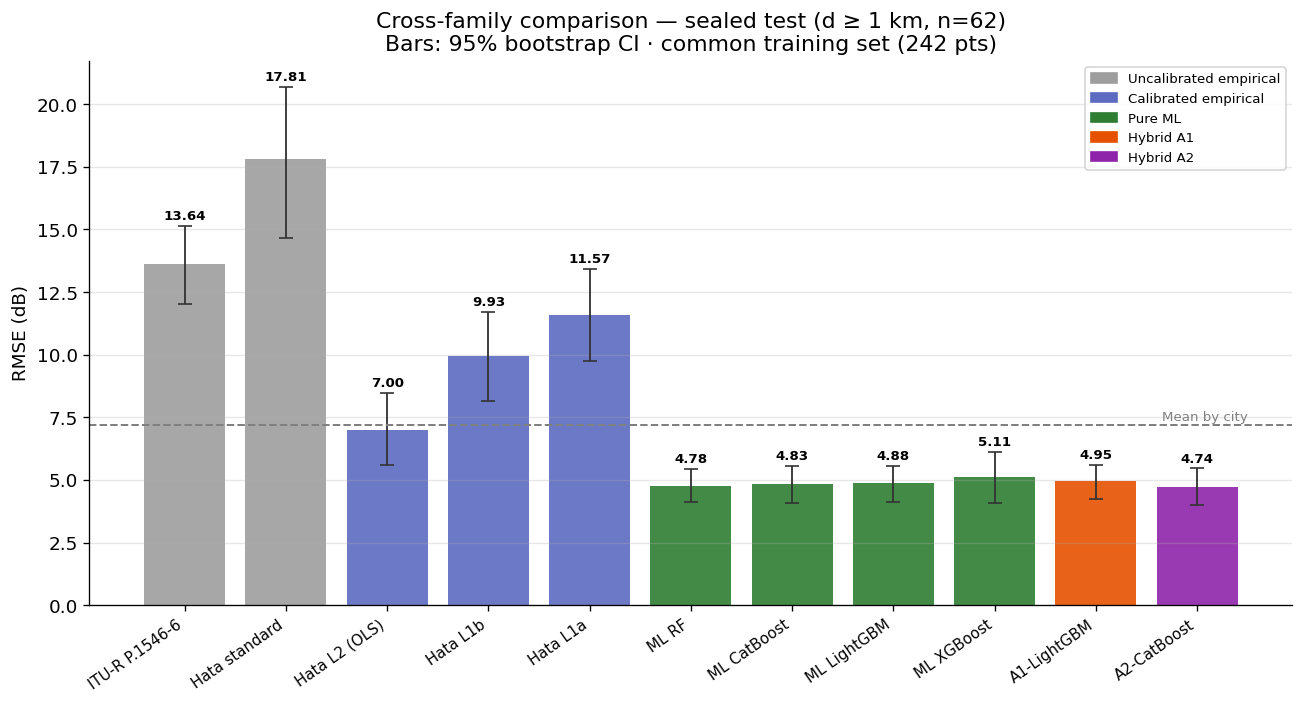

In [9]:
# ── Figure : RMSE avec barres d'erreur ──────────────────────────────────────
s = tab[tab['Famille'] != 'Trivial baseline'].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, 6))
cmap = {'Uncalibrated empirical': '#9E9E9E', 'Calibrated empirical': '#5C6BC0',
        'Pure ML': '#2E7D32', 'Hybrid A1': '#E65100', 'Hybrid A2': '#8E24AA'}
cols = [cmap[f] for f in s['Famille']]
yerr = np.vstack([s['RMSE'] - s['RMSE_lo'], s['RMSE_hi'] - s['RMSE']])
ax.bar(range(len(s)), s['RMSE'], yerr=yerr, capsize=4, color=cols, alpha=0.9,
       error_kw=dict(lw=1.1, ecolor='#333'))
triv = tab[tab['Famille'] == 'Trivial baseline']
for _, r in triv.iterrows():
    ax.axhline(r['RMSE'], ls='--', lw=1.2, color='gray')
    ax.text(len(s)-0.5, r['RMSE']+0.2, r['Modèle'], fontsize=8, color='gray', ha='right')
for i, r in s.iterrows():
    ax.text(i, r['RMSE_hi']+0.25, f"{r['RMSE']:.2f}", ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(range(len(s)))
ax.set_xticklabels(s['Modèle'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('RMSE (dB)')
ax.set_title(f'Cross-family comparison — sealed test (d ≥ 1 km, n={n_test})\n'
             f'Bars: 95% bootstrap CI · common training set ({len(dev_f)} pts)')
ax.grid(axis='y', alpha=0.3)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=f) for f, c in cmap.items()], fontsize=8)
plt.tight_layout()
plt.savefig(OUT / 'fig_cross_family_IC.pdf', bbox_inches='tight')
plt.savefig(OUT / 'fig_cross_family_IC.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Lecture des résultats : ce qui est affirmable et ce qui ne l'est pas ────
sig  = cmp_df[cmp_df['Significatif'] == 'oui']
nsig = cmp_df[cmp_df['Significatif'] == 'non']
print('=== Différences ÉTABLIES (Holm p < 0.05) ===')
for _, r in sig.iterrows():
    meilleur, autre = (r['A'], r['B']) if r['ΔRMSE'] < 0 else (r['B'], r['A'])
    print(f'  {meilleur} < {autre}   (ΔRMSE = {abs(r["ΔRMSE"]):.2f} dB, p = {r["p_Holm"]:.4f})')
print()
print('=== Différences NON établies par Wilcoxon+Holm ===')
for _, r in nsig.iterrows():
    zero_in = (r['IC_lo'] <= 0 <= r['IC_hi'])
    verdict = ('IC contient 0 → aucune différence démontrable'
               if zero_in else
               "IC exclut 0 → les deux tests DIVERGENT, à discuter explicitement")
    print(f'  {r["A"]} vs {r["B"]} : ΔRMSE = {r["ΔRMSE"]:+.2f} dB, '
          f'IC [{r["IC_lo"]:+.2f}, {r["IC_hi"]:+.2f}], p = {r["p_Holm"]:.3f}')
    print(f'      → {verdict}')
print()

=== Différences ÉTABLIES (Holm p < 0.05) ===
  Hata L2 (OLS) < Hata L1b   (ΔRMSE = 2.93 dB, p = 0.0293)
  Hata L2 (OLS) < ITU-R P.1546-6   (ΔRMSE = 6.64 dB, p = 0.0000)

=== Différences NON établies par Wilcoxon+Holm ===
  ML LightGBM vs Hata L2 (OLS) : ΔRMSE = -2.12 dB, IC [-3.57, -0.59], p = 0.323
      → IC exclut 0 → les deux tests DIVERGENT, à discuter explicitement
  ML LightGBM vs Mean by city : ΔRMSE = -2.31 dB, IC [-3.71, -0.86], p = 0.088
      → IC exclut 0 → les deux tests DIVERGENT, à discuter explicitement
  Hata L2 (OLS) vs Mean by city : ΔRMSE = -0.19 dB, IC [-0.64, +0.19], p = 0.631
      → IC contient 0 → aucune différence démontrable
  A1-LightGBM vs ML LightGBM : ΔRMSE = +0.08 dB, IC [-0.51, +0.66], p = 1.000
      → IC contient 0 → aucune différence démontrable
  A2-CatBoost vs ML LightGBM : ΔRMSE = -0.14 dB, IC [-0.55, +0.30], p = 1.000
      → IC contient 0 → aucune différence démontrable
  A1-LightGBM vs A2-CatBoost : ΔRMSE = +0.21 dB, IC [-0.39, +0.82], p = 1.0